1.为了较好的操作，首先会导入一些列必须的包并定义必要的函数

In [2]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax as Softmax
from torchmetrics.functional import pairwise_cosine_similarity
import math
import anndata as ad
import numpy as np
from collections import Counter
from tqdm import tqdm
import math
import scanpy as sc
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from joblib import Parallel, delayed, cpu_count
import pickle
import os

import pandas as pd
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
from scipy.io import mmread
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True


# 下面的是属于conv.py中的代码
class GeneralConv(nn.Module):
    def __init__(self, conv_name, in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm=True):
        super(GeneralConv, self).__init__()
        self.conv_name = conv_name
        # Store attention matrix results
        self.res_att = None
        # Select different graph convolution layers based on the conv_name parameter
        if self.conv_name == 'hgt':
            self.base_conv = HGTConv(in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm)
        elif self.conv_name == 'gcn':
            self.base_conv = GCNConv(in_hid, out_hid)
        elif self.conv_name == 'gat':
            self.base_conv = GATConv(in_hid, out_hid // n_heads, heads=n_heads)

    def forward(self, meta_xs, node_type, edge_index, edge_type):
        if self.conv_name == 'hgt':
            a = self.base_conv(meta_xs, node_type, edge_index, edge_type)
            self.res_att = self.base_conv.res_att
            return a
        elif self.conv_name == 'gcn':
            return self.base_conv(meta_xs, edge_index)
        elif self.conv_name == 'gat':
            return self.base_conv(meta_xs, edge_index)
        elif self.conv_name == 'dense_hgt':
            return self.base_conv(meta_xs, node_type, edge_index, edge_type)


# HGTConv is the heterogeneous graph transformation convolution layer
class HGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True,
                 distribution='uniform', **kwargs):
        super(HGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)

        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_types = num_types
        self.num_relations = num_relations
        self.total_rel = num_types * num_relations * num_types
        self.n_heads = n_heads
        self.d_k = out_dim // n_heads
        self.sqrt_dk = math.sqrt(self.d_k)
        self.use_norm = use_norm
        self.distribution = distribution
        self.att = None
        self.res_att = None
        self.res = None

        self.k_linears = nn.ModuleList()
        self.q_linears = nn.ModuleList()
        self.v_linears = nn.ModuleList()
        self.a_linears = nn.ModuleList()
        self.norms = nn.ModuleList()

        for t in range(num_types):
            self.k_linears.append(nn.Linear(in_dim, out_dim))
            self.q_linears.append(nn.Linear(in_dim, out_dim))
            self.v_linears.append(nn.Linear(in_dim, out_dim))
            self.a_linears.append(nn.Linear(out_dim, out_dim))
            if use_norm:
                self.norms.append(nn.LayerNorm(out_dim))

        self.relation_pri = nn.Parameter(torch.ones(num_relations, self.n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.skip = nn.Parameter(torch.ones(num_types))
        self.drop = nn.Dropout(dropout)

        glorot(self.relation_att)
        glorot(self.relation_msg)

    def _initialize_weights(self):
        for m in self.modules():
            print(m)
            if isinstance(m, nn.Linear):
                if self.distribution == 'uniform':
                    torch.nn.init.xavier_uniform_(m.weight, gain=1)
                if self.distribution == 'normal':
                    torch.nn.init.xavier_normal_(m.weight, gain=1)

    def forward(self, node_inp, node_type, edge_index, edge_type):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type, edge_type=edge_type)

    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type):
        '''
            j: source, i: target; <j, i>
        '''
        data_size = edge_index_i.size(0)

        self.res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)

        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                q_linear = self.q_linears[target_type]
                for relation_type in range(self.num_relations):
                    idx = (edge_type == int(relation_type)) & tb
                    if idx.sum() == 0:
                        continue

                    target_node_vec = node_inp_i[idx]
                    source_node_vec = node_inp_j[idx]

                    q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = torch.bmm(k_mat.transpose(1, 0), self.relation_att[relation_type]).transpose(1, 0)
                    self.res_att[idx] = (q_mat * k_mat).sum(dim=-1) * self.relation_pri[relation_type] / self.sqrt_dk

                    v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    res_msg[idx] = torch.bmm(v_mat.transpose(1, 0), self.relation_msg[relation_type]).transpose(1, 0)

        res = res_msg * Softmax(self.res_att, edge_index_i).view(-1, self.n_heads, 1)

        return res.view(-1, self.out_dim)

    def update(self, aggr_out, node_inp, node_type):
        aggr_out = F.gelu(aggr_out)
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx]))

            alpha = torch.sigmoid(self.skip[target_type])
            if self.use_norm:
                res[idx] = self.norms[target_type](trans_out * alpha + node_inp[idx] * (1 - alpha))
            else:
                res[idx] = trans_out * alpha + node_inp[idx] * (1 - alpha)
        self.res = res
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_types={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim,
            self.num_types, self.num_relations)


# 下面的是属于utils.py中的代码

def subgraph(graph, seed, n_neighbors, node_sele_prob):
    """
    Generates a subgraph starting from a seed node.

    Parameters:
    - graph (scipy.sparse matrix): Adjacency matrix of the graph.
    - seed (int): Seed node ID.
    - n_neighbors (list of int): Number of neighbors to select at each layer.
    - node_sele_prob (np.array): Selection probabilities for nodes.

    Returns:
    - List of selected node indices excluding the seed.
    """
    picked_nodes = {seed}
    last_layer_nodes = {seed}

    # Iteratively select neighbors for each layer
    for layer, n_neighbors_current in enumerate(n_neighbors):
        # Find all neighbors of the last layer nodes
        neighbors = graph[list(last_layer_nodes), :].nonzero()[1]
        neighbors = np.unique(neighbors)

        # If there are no neighbors, terminate early
        if len(neighbors) == 0:
            break

        # Get selection probabilities for the neighbors
        neighbors_prob = node_sele_prob[neighbors]
        neighbors_prob = softmax_stable(neighbors_prob)  # Normalize probabilities

        # Determine the number of neighbors to pick
        to_pick = n_neighbors_current
        n_neighbors_real = min(to_pick, len(neighbors))

        # Select neighbors without replacement based on probabilities
        selected_neighbors = np.random.choice(
            neighbors,
            size=n_neighbors_real,
            replace=False,
            p=neighbors_prob
        )

        # Update the sets of picked and last layer nodes
        last_layer_nodes = set(selected_neighbors)
        picked_nodes.update(last_layer_nodes)

    # Exclude the seed node from the final indices
    indices = sorted(picked_nodes - {seed})
    return indices


def batch_select_whole(RNA_matrix, neighbor=[20], cell_size=30, save_path='processed_data_subset'):
    """
    修改后的函数，支持数据的保存和并行处理。
    """
    # 检查是否已经存在处理后的数据
    indices_ss_file = os.path.join(save_path, 'indices_ss.pkl')
    Node_Ids_file = os.path.join(save_path, 'Node_Ids.pkl')
    dic_file = os.path.join(save_path, 'dic.pkl')

    if os.path.exists(indices_ss_file) and os.path.exists(Node_Ids_file) and os.path.exists(dic_file):
        print('正在从磁盘加载处理后的数据...')
        with open(indices_ss_file, 'rb') as f:
            indices_ss = pickle.load(f)
        with open(Node_Ids_file, 'rb') as f:
            Node_Ids = pickle.load(f)
        with open(dic_file, 'rb') as f:
            dic = pickle.load(f)
    else:
        print('正在将数据划分为批次并进行并行处理。请稍候...')

        # 打乱细胞 ID
        Node_Ids = np.random.choice(RNA_matrix.shape[1], size=RNA_matrix.shape[1], replace=False)
        n_batch = math.ceil(Node_Ids.shape[0] / cell_size)
        indices_ss = []

        RNA_matrix = RNA_matrix.tocsr()  # 确保行切片效率高
        dic = {}

        for i in tqdm(range(n_batch), desc="处理批次"):
            gene_indices_all = []
            cell_indices_all = []

            # 确定当前批次的范围
            start_idx = i * cell_size
            end_idx = min((i + 1) * cell_size, Node_Ids.shape[0])
            batch_node_ids = Node_Ids[start_idx:end_idx]

            # 并行处理每个节点
            results = Parallel(n_jobs=max(1, cpu_count() // 2))(
                delayed(process_node)(node, RNA_matrix, neighbor) for node in batch_node_ids
            )

            for node, gene_indices in results:
                dic[node] = {'g': gene_indices}
                gene_indices_all.extend(gene_indices)

            # 移除重复的基因索引
            gene_indices_all = sorted(set(gene_indices_all))

            # 准备批次字典
            batch_dict = {
                'gene_index': gene_indices_all,
                'cell_index': list(batch_node_ids)
            }
            indices_ss.append(batch_dict)

        # 保存处理后的数据
        os.makedirs(save_path, exist_ok=True)
        with open(indices_ss_file, 'wb') as f:
            pickle.dump(indices_ss, f)
        with open(Node_Ids_file, 'wb') as f:
            pickle.dump(Node_Ids, f)
        with open(dic_file, 'wb') as f:
            pickle.dump(dic, f)

    return indices_ss, Node_Ids, dic


def process_node(node, RNA_matrix, neighbor):
    # 提取当前细胞的基因表达
    rna_expression = RNA_matrix[:, node].toarray().flatten()
    rna_expression[rna_expression < 5] = 0  # 阈值处理

    # 计算选择概率
    selection_prob = np.log(rna_expression + 1)
    selection_prob = np.squeeze(selection_prob)

    # 为当前细胞生成子图
    gene_indices = subgraph(RNA_matrix.transpose(), node, neighbor, selection_prob)

    return node, gene_indices


def softmax_stable(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()


def softmax_simple(x):
    return np.exp(x) / np.exp(x).sum()


class LabelSmoothing(torch.nn.Module):
    """NLL loss with label smoothing.
    """

    def __init__(self, smoothing=0.0, num_classes=10):
        """Constructor for LabelSmoothing module.
        :param smoothing: Label smoothing factor
        """
        super(LabelSmoothing, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, x, target):
        logprobs = torch.nn.functional.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

    def update_num_classes(self, new_num_classes):
        self.num_classes = new_num_classes


def initial_clustering(RNA_matrix, custom_n_neighbors=None, n_pcs=40, custom_resolution=None, use_rep=None):
    print(
        '\tWhen the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.')
    print('\tWhen the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.')
    print('\tWhen the number of cells is greater than 5000, the resolution value should be set to 0.8.')

    def segment_function(x):
        if x <= 500:
            return 0.2, 5
        elif x <= 5000:
            return 0.5, 10
        else:
            return 0.8, 15

    adata = ad.AnnData(RNA_matrix.transpose(), dtype='int32')

    # If the user did not provide a custom resolution or n_neighbors value, use the values calculated by segment_function
    if custom_resolution is None or custom_n_neighbors is None:
        resolution, n_neighbors = segment_function(adata.shape[0])
    else:
        resolution = custom_resolution
        n_neighbors = custom_n_neighbors

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # Use the user-provided embedding if available, otherwise use n_pcs
    if use_rep is not None:
        adata.obsm['use_rep'] = use_rep
        sc.pp.neighbors(adata, use_rep='use_rep', n_neighbors=n_neighbors)
    else:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs)

    sc.tl.leiden(adata, resolution)
    return adata.obs['leiden']


def purity_score(y_true, y_pred):
    """Purity score

    Args:
        y_true (np.ndarray): n*1 matrix, true labels
        y_pred (np.ndarray): n*1 matrix, predicted clusters

    Returns:
        float: Purity score
    """
    # Create a matrix to store the majority-voted labels
    y_voted_labels = np.zeros(y_true.shape)

    # Sort the labels
    # Some labels might be missing, e.g., a set {0,2} where 1 is missing
    # First, find the unique labels and then map them to an ordered set
    # E.g., {0,2} should be mapped to {0,1}
    labels = np.unique(y_true)
    ordered_labels = np.arange(labels.shape[0])
    for k in range(labels.shape[0]):
        y_true[y_true == labels[k]] = ordered_labels[k]
    y_true = np.array(y_true, dtype='int64')

    # Update the unique labels
    labels = np.unique(y_true)

    # Set the number of bins to n_classes + 2 so that we can compute the actual
    # class occurrences between two consecutive bins
    # The larger bin is excluded: [bin_i, bin_i+1[
    bins = np.concatenate((labels, [np.max(labels) + 1]), axis=0)

    for cluster in np.unique(y_pred):
        hist, _ = np.histogram(y_true[y_pred == cluster], bins=bins)
        # Find the most frequent label in the cluster
        winner = np.argmax(hist)
        y_voted_labels[y_pred == cluster] = winner

    y_true = np.array(y_true, dtype='int8')
    y_voted_labels = np.array(y_voted_labels, dtype='int8')
    return accuracy_score(y_true, y_voted_labels), y_true


def Entropy(pred_label, true_label):
    e = 0
    for k in set(pred_label):
        en = 0
        pred_k = Counter(pred_label)[k]
        index_pred_k = pred_label == k
        for j in set(true_label):
            true_j = Counter(true_label)[j]
            intersection_kj = (true_label[index_pred_k] == j).sum()
            p = np.array(intersection_kj) / np.array(pred_k)
            if p != 0:
                en += np.log(p) * p
        e = e + en * pred_k / true_label.shape[0]
    return abs(e)


# model.py

class GNN_from_raw(nn.Module):
    def __init__(self, in_dim, n_hid, num_types, num_relations, n_heads, n_layers, dropout=0.2, conv_name='hgt',
                 prev_norm=True, last_norm=True):
        super(GNN_from_raw, self).__init__()
        self.gcs = nn.ModuleList()
        self.num_types = num_types
        self.in_dim = in_dim
        self.n_hid = n_hid
        self.adapt_ws = nn.ModuleList()
        self.drop = nn.Dropout(dropout)
        self.embedding1 = nn.ModuleList()

        # Initialize MLP weight matrices
        for ti in range(num_types):
            self.embedding1.append(nn.Linear(in_dim[ti], 256))

        for t in range(num_types):
            self.adapt_ws.append(nn.Linear(256, n_hid))

        # Initialize graph convolution layers
        for l in range(n_layers - 1):
            self.gcs.append(
                GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=prev_norm))
        self.gcs.append(
            GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=last_norm))

    def encode(self, x, t_id):
        h1 = F.relu(self.embedding1[t_id](x))
        return h1

    def forward(self, node_feature, node_type, edge_index, edge_type):
        node_embedding = []
        for t_id in range(self.num_types):
            node_embedding += list(self.encode(node_feature[t_id], t_id))

        node_embedding = torch.stack(node_embedding)
        # Initialize result matrix
        res = torch.zeros(node_embedding.size(0), self.n_hid).to(node_feature[0].device)

        # Process each node type
        for t_id in range(self.num_types):
            idx = (node_type == int(t_id))
            if idx.sum() == 0:
                continue
            # Update result matrix
            res[idx] = torch.tanh(self.adapt_ws[t_id](node_embedding[idx]))

        # Apply dropout to the result matrix
        meta_xs = self.drop(res)
        del res

        # Iterate through graph convolution layers and update result matrix
        for gc in self.gcs:
            meta_xs = gc(meta_xs, node_type, edge_index, edge_type)

        return meta_xs


class Net(nn.Module):
    def __init__(self, dim_in, dim_out):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(dim_in, dim_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return x


class NDR_1(nn.Module):
    def __init__(self, RNA_matrix, indices, ini_p1, n_hid, n_heads,
                 n_layers, labsm, lr, wd, device, num_types=2, num_relations=2, epochs=1, loss_contrastive_weight=0):
        super(NDR_1, self).__init__()
        self.RNA_matrix = RNA_matrix
        self.indices = indices
        self.ini_p1 = ini_p1
        self.in_dim = [RNA_matrix.shape[0], RNA_matrix.shape[1]]  # 仅包含基因和细胞的维度
        self.n_hid = n_hid
        self.num_types = num_types  # 2 种类型：细胞和基因
        self.num_relations = num_relations  # 2 种关系：基因到细胞和细胞到基因
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.labsm = labsm
        self.lr = lr
        self.wd = wd
        self.device = device
        self.epochs = epochs
        self.loss_contrastive_weight = loss_contrastive_weight  # 新增超参数

        # 标签平滑
        self.LabSm = LabelSmoothing(self.labsm)

        # GNN 模型
        self.gnn = GNN_from_raw(in_dim=self.in_dim,
                                n_hid=self.n_hid,
                                num_types=self.num_types,
                                num_relations=self.num_relations,
                                n_heads=self.n_heads,
                                n_layers=self.n_layers,
                                dropout=0.3).to(self.device)

        # 优化器和学习率调度器
        self.optimizer = torch.optim.AdamW(self.gnn.parameters(), lr=self.lr, weight_decay=self.wd)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, 'min', factor=0.5, patience=5,
                                                                    verbose=True)

    def supervised_contrastive_loss(self, features, labels, batch_labels=None, temperature=0.07):
        """
        Compute supervised contrastive loss with batch labels.

        Args:
            features: tensor of shape [batch_size, embedding_dim]
            labels: tensor of shape [batch_size]
            batch_labels: tensor of shape [batch_size], indicating the batch assignments (optional)
            temperature: a float scalar temperature

        Returns:
            loss: a scalar loss value
        """
        # Normalize features
        features = F.normalize(features, dim=1)
        batch_size = features.shape[0]

        epsilon = 1e-10  # 防止除以零或对数零

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / temperature

        # Clamp similarity_matrix to prevent large values
        max_sim = 50  # 可以根据需要调整
        min_sim = -50
        similarity_matrix = torch.clamp(similarity_matrix, min=min_sim, max=max_sim)

        # Create masks
        labels = labels.contiguous().view(-1, 1)
        if labels.shape[0] != batch_size:
            raise ValueError('Number of labels does not match number of features')

        # Positive mask: labels match
        label_eq = torch.eq(labels, labels.T).float().to(features.device)

        # If batch labels are provided, ensure positives come from different batches
        if batch_labels is not None:
            batch_labels = batch_labels.contiguous().view(-1, 1)
            batch_neq = (~torch.eq(batch_labels, batch_labels.T)).float().to(features.device)
            mask = label_eq * batch_neq
        else:
            # If no batch labels, use label matching only
            mask = label_eq

        # Remove self-contrast cases
        logits_mask = torch.ones_like(mask) - torch.eye(batch_size).to(features.device)
        mask = mask * logits_mask

        # Compute log_prob
        exp_sim = torch.exp(similarity_matrix) * logits_mask
        exp_sim_sum = exp_sim.sum(1, keepdim=True) + epsilon  # 添加 epsilon 防止 log(0)
        log_prob = similarity_matrix - torch.log(exp_sim_sum)

        # Compute mean of log-likelihood over positive
        mask_sum = mask.sum(1)
        # 避免除以零
        mean_log_prob_pos = torch.zeros_like(mask_sum)
        non_zero_mask = mask_sum > 0
        mean_log_prob_pos[non_zero_mask] = ((mask * log_prob).sum(1)[non_zero_mask]) / mask_sum[non_zero_mask]

        # Loss
        loss = -mean_log_prob_pos
        # Avoid NaNs
        loss = loss[non_zero_mask].mean()
        return loss

    def train_model(self, n_batch, batch_labels_list=None):
        """
        Args:
            n_batch: number of batches
            batch_labels_list: (optional) a list where each element is a tensor of batch labels for the cells in that batch
        """
        print('The training process for the NodeDimensionReduction model has started. Please wait.')
        h_final = None  # 用于存储最后一个 h
        for epoch in tqdm(range(self.epochs), desc="Epochs"):
            for batch_id in range(n_batch):
                # 获取当前批次的基因和细胞索引
                gene_index = self.indices[batch_id]['gene_index']
                cell_index = self.indices[batch_id]['cell_index']

                # 提取基因和细胞的特征
                gene_feature = self.RNA_matrix[list(gene_index), :]
                cell_feature = self.RNA_matrix[:, list(cell_index)].T

                # 转换为张量并移动到设备上
                gene_feature = torch.tensor(gene_feature.todense(), dtype=torch.float32).to(self.device)
                cell_feature = torch.tensor(cell_feature.todense(), dtype=torch.float32).to(self.device)

                # 构建节点特征列表（细胞和基因）
                node_feature = [cell_feature, gene_feature]

                # 构建基因-细胞子图的邻接矩阵
                gene_cell_sub = self.RNA_matrix[list(gene_index), :][:, list(cell_index)]

                # 构建基因到细胞的边索引
                gene_to_cell_src = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))  # 基因索引从 len(cell_index) 开始
                gene_to_cell_dst = list(np.nonzero(gene_cell_sub)[1])

                # 构建细胞到基因的边索引
                cell_to_gene_src = list(np.nonzero(gene_cell_sub)[1])
                cell_to_gene_dst = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))  # 基因索引

                # 合并边索引
                edge_index = torch.LongTensor([
                    gene_to_cell_src + cell_to_gene_src,  # 源节点
                    gene_to_cell_dst + cell_to_gene_dst  # 目标节点
                ]).to(self.device)

                # 定义节点类型：0 代表细胞，1 代表基因
                node_type = torch.LongTensor(
                    np.array(
                        list(np.zeros(len(cell_index))) + list(np.ones(len(gene_index)))
                    )
                ).to(self.device)

                # 定义边类型：0 代表基因到细胞，1 代表细胞到基因
                edge_type_gene_to_cell = np.zeros(len(gene_to_cell_src), dtype=int)
                edge_type_cell_to_gene = np.ones(len(cell_to_gene_src), dtype=int)
                edge_type = torch.LongTensor(
                    np.concatenate([edge_type_gene_to_cell, edge_type_cell_to_gene])
                ).to(self.device)

                # 获取标签
                l = torch.LongTensor(np.array(self.ini_p1)[cell_index]).to(self.device)

                # 获取批次标签
                # batch_labels = batch_labels_list[batch_id]
                # batch_labels = torch.LongTensor(batch_labels).to(self.device)
                if batch_labels_list is not None:
                    batch_labels = batch_labels_list[batch_id]
                    batch_labels = torch.LongTensor(batch_labels).to(self.device)
                else:
                    batch_labels = None

                # ==============
                # print("node_feature:", node_feature)
                # print("node_type:", node_type)
                # print("edge_index:", edge_index)
                # print("edge_type:", edge_type)
                #
                # node_rep = self.gnn.forward(node_feature, node_type, edge_index, edge_type)
                # if torch.isnan(node_rep).any():
                #     print("node_rep contains NaN values.")
                # 可以在这里中断或返回，避免继续计算
                # ===============

                # 前向传播
                node_rep = self.gnn.forward(node_feature, node_type, edge_index, edge_type).to(self.device)
                cell_emb = node_rep[node_type == 0]
                gene_emb = node_rep[node_type == 1]

                # 解码器：基因与细胞的关系
                decoder_gene_to_cell = torch.mm(gene_emb, cell_emb.t())
                decoder_cell_to_gene = torch.mm(cell_emb, gene_emb.t())

                # 构建目标矩阵
                gene_cell_sub_tensor = torch.tensor(gene_cell_sub.todense(), dtype=torch.float32).to(self.device)

                # 计算基因到细胞的 KL 散度损失
                logp_x1 = F.log_softmax(decoder_gene_to_cell, dim=-1)
                p_y1 = F.softmax(gene_cell_sub_tensor, dim=-1)
                loss_kl1 = F.kl_div(logp_x1, p_y1, reduction='mean')

                # 计算细胞到基因的 KL 散度损失
                logp_x2 = F.log_softmax(decoder_cell_to_gene, dim=-1)
                p_y2 = F.softmax(gene_cell_sub_tensor.t(), dim=-1)
                loss_kl2 = F.kl_div(logp_x2, p_y2, reduction='mean')

                # 总的 KL 散度损失
                loss_kl = loss_kl1 + loss_kl2

                # 聚类损失
                loss_cluster = self.LabSm(cell_emb, l)

                # 余弦相似度损失
                lll = 0
                g = l.tolist()
                unique_labels = set(g)
                for label in unique_labels:
                    mask = np.array(g) == label
                    h = cell_emb[mask]
                    if h.size(0) > 1:
                        # 计算细胞间的余弦相似度
                        similarity = F.cosine_similarity(h.unsqueeze(1), h.unsqueeze(0), dim=-1)
                        lll += similarity.mean()
                        h_final = h  # 更新 h_final 为当前标签的 h

                # 对比学习损失
                loss_contrastive = self.supervised_contrastive_loss(cell_emb, l, batch_labels)

                # 总损失
                loss = loss_cluster + loss_kl + self.loss_contrastive_weight * loss_contrastive - lll
                # loss = loss_cluster + loss_kl - lll

                # 反向传播和优化
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

        print('The training for the NodeDimensionReduction model has been completed.')
        return self.gnn, cell_emb, gene_emb, h_final  # 返回 h_final

    def save_model(self, file_path):
        """保存训练好的模型"""
        torch.save(self.gnn.state_dict(), file_path)

    def load_model(self, file_path):
        """加载保存的模型

        Args:
            file_path (str): 模型文件的路径
        """
        # 加载模型的状态字典
        state_dict = torch.load(file_path, map_location=self.device)
        # 将状态字典加载到 GNN 模型中
        self.gnn.load_state_dict(state_dict)
        # 将模型移动到指定的设备
        self.gnn.to(self.device)
        # 设置模型为评估模式（如果需要进行推理）
        self.gnn.eval()
        print(f"Model loaded successfully from {file_path}.")


def HGT_pre(RNA_matrix, gnn, indices, device, cell_size=30):
    """
    Use the trained ScFormer model for prediction.

    :param RNA_matrix: Gene expression matrix (scipy.sparse or similar format)
    :param gnn: Trained ScFormer model
    :param indices: List of batch indices, each containing 'gene_index' and 'cell_index'
    :param device: Computation device (e.g., torch.device('cuda') or torch.device('cpu'))
    :param cell_size: Number of cells to process in each batch
    :return: Dictionary containing predicted labels (if applicable) and cell embeddings
    """
    n_cells = RNA_matrix.shape[1]
    n_batch = len(indices)
    embedding_dim = gnn.n_hid  # Assuming the hidden dimension is the embedding dimension

    # Initialize an array to store cell embeddings
    cell_embedding = np.zeros((n_cells, embedding_dim))

    ScFormer_result = {}
    with torch.no_grad():
        for batch_id in tqdm(range(n_batch), desc="Prediction Batches"):
            gene_index = indices[batch_id]['gene_index']
            cell_index = indices[batch_id]['cell_index']

            # Extract features for genes and cells
            gene_feature = RNA_matrix[list(gene_index), :]
            cell_feature = RNA_matrix[:, list(cell_index)].T

            # Convert to tensors and move to device
            gene_feature = torch.tensor(gene_feature.todense(), dtype=torch.float32).to(device)
            cell_feature = torch.tensor(cell_feature.todense(), dtype=torch.float32).to(device)

            # Build node features list (cells and genes)
            node_feature = [cell_feature, gene_feature]

            # Build gene-cell subgraph adjacency matrix
            gene_cell_sub = RNA_matrix[list(gene_index), :][:, list(cell_index)]

            # Build edge indices
            gene_to_cell_src = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            gene_to_cell_dst = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_src = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_dst = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            edge_index = torch.LongTensor([
                gene_to_cell_src + cell_to_gene_src,
                gene_to_cell_dst + cell_to_gene_dst
            ]).to(device)

            # Define node types: 0 for cells, 1 for genes
            node_type = torch.LongTensor(
                np.array(
                    list(np.zeros(len(cell_index), dtype=int)) + list(np.ones(len(gene_index), dtype=int))
                )
            ).to(device)

            # Define edge types: 0 for gene to cell, 1 for cell to gene
            edge_type_gene_to_cell = np.zeros(len(gene_to_cell_src), dtype=int)
            edge_type_cell_to_gene = np.ones(len(cell_to_gene_src), dtype=int)
            edge_type = torch.LongTensor(
                np.concatenate([edge_type_gene_to_cell, edge_type_cell_to_gene])
            ).to(device)

            # Forward pass through the GNN model
            node_rep = gnn(node_feature, node_type, edge_index, edge_type)
            cell_emb = node_rep[node_type == 0]
            # gene_emb = node_rep[node_type == 1]  # If needed elsewhere

            # Store cell embeddings in the correct positions
            cell_embedding[cell_index] = cell_emb.cpu().numpy()

    # Since we might not have labels during prediction, we can return embeddings
    ScFormer_result = {'cell_embedding': cell_embedding}
    return ScFormer_result

2.数据太大了，模型训练太慢，我会在这里创建一个比较小的数据集

In [26]:
# adata_151673 = sc.read_10x_mtx('data/DLPFC/151673/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
# metadata = pd.read_csv('data/DLPFC/151673/metadata.csv')
# adata_151673.obs = metadata
# adata_151673.var_names_make_unique()

# adata_151674 = sc.read_10x_mtx('data/DLPFC/151672/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
# metadata = pd.read_csv('data/DLPFC/151672/metadata.tsv')
# adata_151674.obs = metadata
# adata_151674.var_names_make_unique()

# adata_151673.obs['batch'] = 'batch_1'
# adata_151674.obs['batch'] = 'batch_2'
# adata = sc.concat([adata_151673, adata_151674], join='outer', label='batch', keys=['batch1', 'batch2'])

In [4]:
# HD1_gene_cell = ad.read_mtx('data/pbmcs_multiple_sample/HD1/Gene_Cell.mtx')
# HD1_adata = sc.AnnData(HD1_gene_cell.transpose())
# 
# HD1_gene_names = pd.read_csv('data/pbmcs_multiple_sample/HD1/Gene_names.tsv', sep='\t', header=None)
# HD1_cell_names = pd.read_csv('data/pbmcs_multiple_sample/HD1/Cell_names.tsv', sep='\t', header=None)
# 
# HD1_adata.var_names = HD1_gene_names[0]
# HD1_adata.obs_names = HD1_cell_names[0]
# 
# P1_gene_cell = ad.read_mtx('data/pbmcs_multiple_sample/P1/Gene_Cell.mtx')
# P1_adata = sc.AnnData(P1_gene_cell.transpose())
# 
# P1_gene_names = pd.read_csv('data/pbmcs_multiple_sample/P1/Gene_names.tsv', sep='\t', header=None)
# P1_cell_names = pd.read_csv('data/pbmcs_multiple_sample/P1/Cell_names.tsv', sep='\t', header=None)
# 
# P1_adata.var_names = P1_gene_names[0]
# P1_adata.obs_names = P1_cell_names[0]
# 
# HD1_adata.obs['batch'] = 'batch1'
# P1_adata.obs['batch'] = 'batch2'
# adata = ad.concat([HD1_adata, P1_adata], join='outer', label='batch', keys=['batch1', 'batch2'])
# adata

In [7]:
adata = sc.read_h5ad('cache/pan_cancer_matrix.h5ad')
adata_ESCA = adata[adata.obs['Cancer'] == 'ESCA']
adata_ESCA_tumor = adata_ESCA[adata_ESCA.obs['Tissue'] == 'Tumor']
adata_ESCA_tumor

View of AnnData object with n_obs × n_vars = 6087 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [16]:
sample_id = adata_ESCA_tumor.obs['SampleID'].unique()[0:2]

In [17]:
adata_ESCA_tumor_2 = adata_ESCA_tumor[adata_ESCA_tumor.obs['SampleID'].isin(sample_id)]
adata_ESCA_tumor_2

View of AnnData object with n_obs × n_vars = 1140 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [18]:
adata_subset = adata_ESCA_tumor_2

In [10]:
selected_indices = np.random.choice(adata_ESCA_tumor.n_obs, size=500, replace=False)
adata_subset = adata_ESCA_tumor[selected_indices].copy()
adata_subset

AnnData object with n_obs × n_vars = 500 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

         Falling back to preprocessing with `sc.pp.pca` and default params.


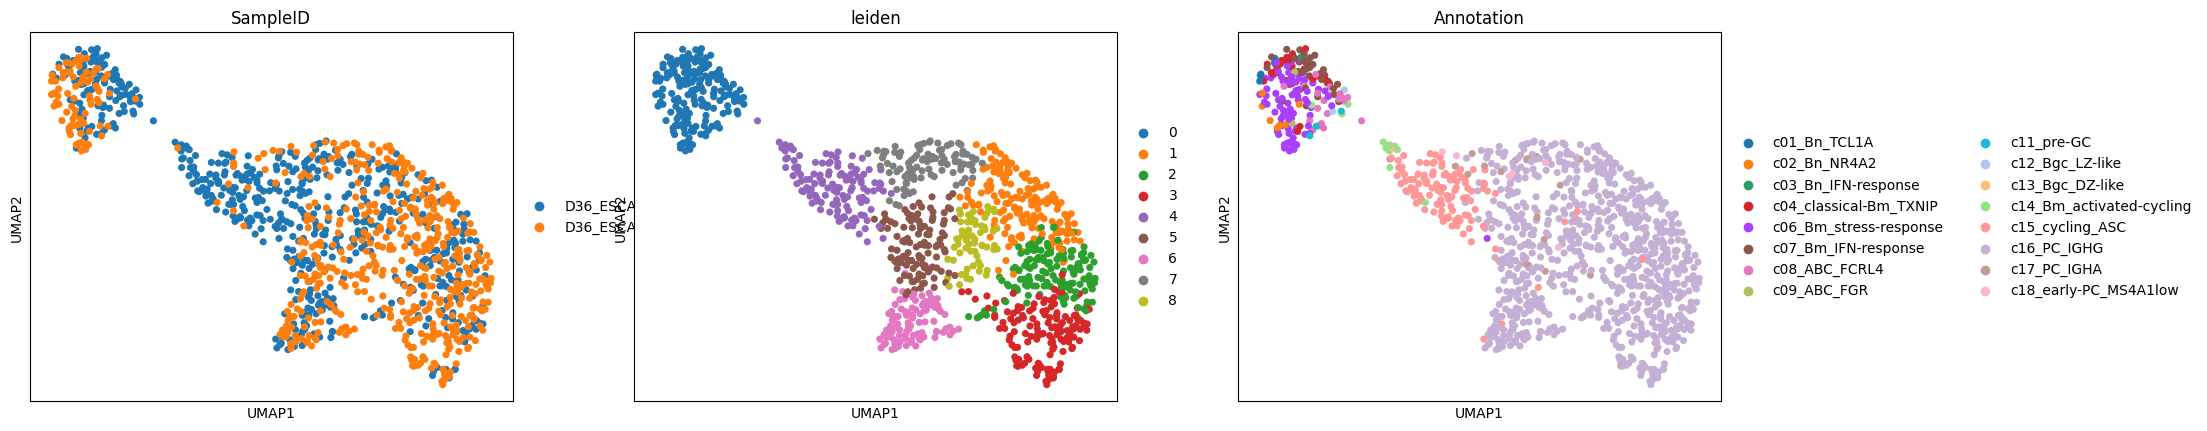

In [19]:
adata_subset.raw = adata_subset.copy()
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, zero_center=True)
sc.pp.neighbors(adata_subset)
sc.tl.leiden(adata_subset)
sc.tl.umap(adata_subset)
sc.pl.umap(adata_subset, color=['SampleID', 'leiden', 'Annotation'], show=True)

In [20]:
adata_subset.X = csr_matrix(adata_subset.X)

In [21]:
RNA_matrix = adata_subset.X.transpose()

In [22]:
cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 30

initial_pre = initial_clustering(adata_subset.raw.X)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size)
n_batch = len(indices)

output_file = 'data/DLPFC/output/different_samples_1'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)

device = torch.device("cuda" if cuda.is_available() else "cpu")

node_model = NDR_1(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)
node_model.save_model('new_model_1.pth')
ScFormer_result = HGT_pre(RNA_matrix, gnn=gnn, indices=indices, device=device, cell_size=cell_size)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
正在将数据划分为批次并进行并行处理。请稍候...


处理批次: 100%|██████████| 38/38 [00:20<00:00,  1.86it/s]


The training process for the NodeDimensionReduction model has started. Please wait.


Epochs: 100%|██████████| 100/100 [07:27<00:00,  4.47s/it]


The training for the NodeDimensionReduction model has been completed.


Prediction Batches: 100%|██████████| 38/38 [00:02<00:00, 13.40it/s]


In [23]:
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

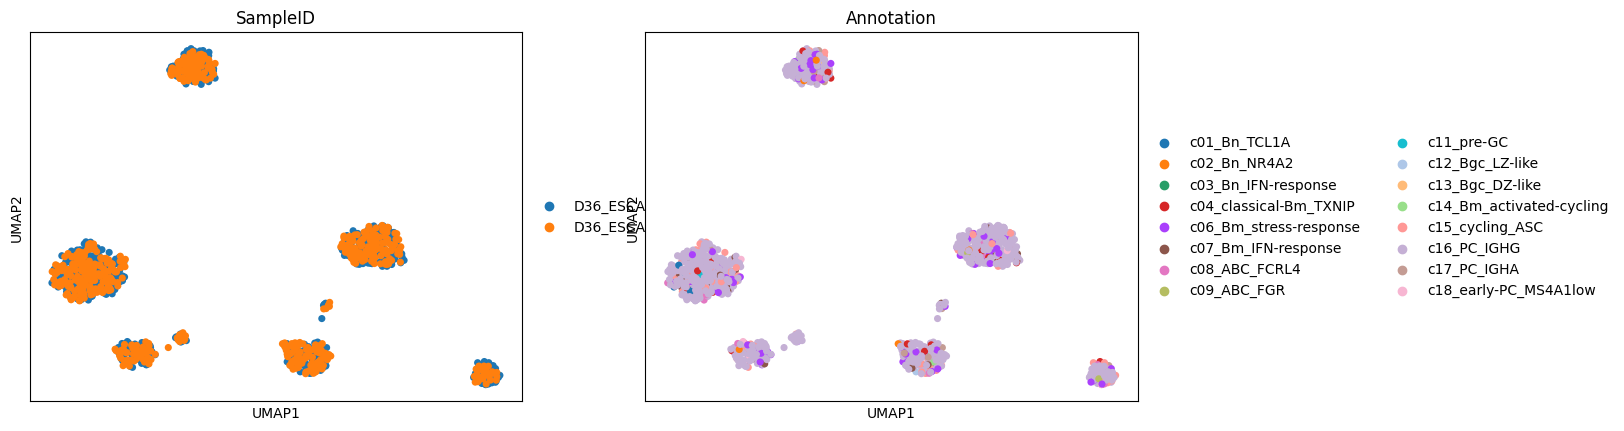

In [24]:
Node_Ids = np.load('data/DLPFC/output/different_samples_1/Node_Ids.npy')
# Node_Ids
cell_emb = np.load('data/DLPFC/output/different_samples_1/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata_subset.obsm['cell_emb'] = cell_emb_sorted.values
# pred = np.load('data/DLPFC/output/different_samples/pred.npy')
# pred_ = pd.DataFrame(pred, index=Node_Ids)
# pred_sorted = pred_.sort_index()
# adata.obs['pre'] = pred_sorted.values
# adata.obs['pre'] = adata.obs['pre'].astype('category')
# adata
adata_subset.var_names_make_unique()
sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_subset, use_rep='cell_emb')
sc.tl.umap(adata_subset)
sc.pl.umap(adata_subset, color=['SampleID', 'Annotation'], show=True)